In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


In [3]:
DATA_PATH = "smart_grid_load_dataset.csv"

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,timestamp,load_MW,temperature_C,humidity,wind_speed,hour,day_of_week,is_weekend,lag_1,lag_24,rolling_mean_3
0,2022-01-01 00:00:00,30548.354221,9.228418,76.640011,4.562699,0,5,1,NaN,NaN,NaN
1,2022-01-01 01:00:00,31207.470993,12.197539,67.038840,5.765877,1,5,1,30548.354221,NaN,NaN
2,2022-01-01 02:00:00,33199.328607,9.775760,69.334136,6.470284,2,5,1,31207.470993,NaN,31651.717940
3,2022-01-01 03:00:00,35110.203831,10.353272,68.246176,2.633271,3,5,1,33199.328607,NaN,33172.334477
4,2022-01-01 04:00:00,34147.613713,11.606915,75.140537,5.201478,4,5,1,35110.203831,NaN,34152.382050


In [4]:
# --- Schema checks & time-series validation ---
expected_cols = {
    "timestamp", "load_MW", "temperature_C", "humidity", "wind_speed",
    "hour", "day_of_week", "is_weekend",
    "lag_1", "lag_24", "rolling_mean_3",
}

missing_expected = sorted(list(expected_cols - set(df_raw.columns)))
extra_cols = sorted(list(set(df_raw.columns) - expected_cols))

print("Missing expected columns:", missing_expected)
print("Extra columns:", extra_cols)

df = df_raw.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

dup_ts = df["timestamp"].duplicated().sum()
nan_ts = df["timestamp"].isna().sum()
print(f"Timestamp parse NaNs: {nan_ts}")
print(f"Duplicate timestamps: {dup_ts}")

# Drop rows where timestamp couldn't be parsed
df = df.dropna(subset=["timestamp"]).copy()

# Sort by time (critical for lag/rolling and time-based splits)
df = df.sort_values("timestamp").reset_index(drop=True)

print("Rows after timestamp parse:", len(df))

# Frequency/gap check (expected: hourly)
time_deltas = df["timestamp"].diff().dropna()
mode_delta = time_deltas.mode().iloc[0]
non_hourly = (time_deltas != mode_delta).sum()
print("Most common delta:", mode_delta)
print("Non-common-delta count:", non_hourly)

core_feature_cols = [
    "temperature_C", "humidity", "wind_speed", "hour", "day_of_week", "is_weekend",
    "lag_1", "lag_24", "rolling_mean_3",
]

print("Missing values per column (top):")
print(df[["load_MW"] + core_feature_cols].isna().sum().sort_values(ascending=False).head(15))


Missing expected columns: []
Extra columns: []
Timestamp parse NaNs: 0
Duplicate timestamps: 0
Rows after timestamp parse: 40000
Most common delta: 0 days 01:00:00
Non-common-delta count: 0
Missing values per column (top):
load_MW           200
temperature_C     200
lag_24             24
rolling_mean_3      2
lag_1               1
humidity            0
day_of_week         0
hour                0
wind_speed          0
is_weekend          0
dtype: int64


In [5]:
# --- Derived feature verification (avoid leakage) ---
# Recompute lag/rolling using a safe definition based on sorted time.
df_check = df[["timestamp", "load_MW"]].copy()
df_check["lag_1_calc"] = df_check["load_MW"].shift(1)
df_check["lag_24_calc"] = df_check["load_MW"].shift(24)
df_check["rolling_mean_3_calc"] = (
    df_check["load_MW"].shift(1).rolling(window=3, min_periods=3).mean()
)

compare_cols = [
    ("lag_1", "lag_1_calc"),
    ("lag_24", "lag_24_calc"),
    ("rolling_mean_3", "rolling_mean_3_calc"),
]

report_rows = []
TOL = 1e-6
for provided_col, calc_col in compare_cols:
    provided = df[provided_col]
    calc = df_check[calc_col]
    mask = (~provided.isna()) & (~calc.isna())
    if mask.sum() == 0:
        report_rows.append({
            "feature": provided_col,
            "n_compared": 0,
            "max_abs_diff": np.nan,
            "mean_abs_diff": np.nan,
            "pct_within_tol": np.nan,
        })
        continue
    diffs = (provided[mask] - calc[mask]).abs()
    report_rows.append({
        "feature": provided_col,
        "n_compared": int(mask.sum()),
        "max_abs_diff": float(diffs.max()),
        "mean_abs_diff": float(diffs.mean()),
        "pct_within_tol": float((diffs <= TOL).mean() * 100.0),
    })

pd.DataFrame(report_rows).sort_values("feature")

,feature,n_compared,max_abs_diff,mean_abs_diff,pct_within_tol
0,lag_1,39799,0.000000,0.000000,100.0
1,lag_24,39776,0.000000,0.000000,100.0
2,rolling_mean_3,39398,2983.343594,871.044819,0.0


In [6]:
# Use the safe recomputed versions for modeling.
df["lag_1"] = df_check["lag_1_calc"]
df["lag_24"] = df_check["lag_24_calc"]
df["rolling_mean_3"] = df_check["rolling_mean_3_calc"]

del df_check

print("Core feature columns used:")
print(core_feature_cols)


Core feature columns used:
['temperature_C', 'humidity', 'wind_speed', 'hour', 'day_of_week', 'is_weekend', 'lag_1', 'lag_24', 'rolling_mean_3']


EXPLORATORY DATA ANALYSIS


In [7]:
# --- Missingness overview ---
target_col = "load_MW"

eda_cols = [target_col] + core_feature_cols
missing_counts = df[eda_cols].isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100.0).round(2)

missing_table = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_table

,missing_count,missing_pct
rolling_mean_3,602,1.50
lag_24,224,0.56
lag_1,201,0.50
load_MW,200,0.50
temperature_C,200,0.50
humidity,0,0.00
day_of_week,0,0.00
hour,0,0.00
wind_speed,0,0.00
is_weekend,0,0.00


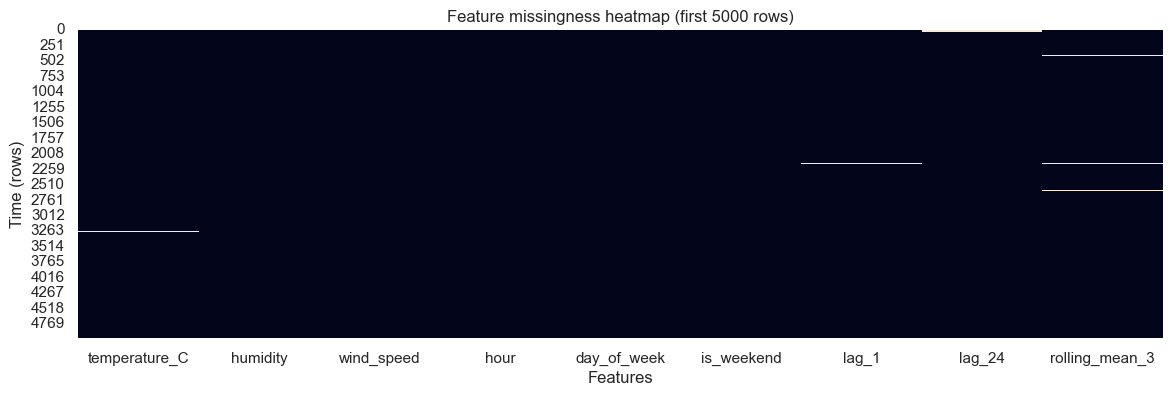

In [8]:
# Missingness heatmap (zoomed to early rows where lags/rolling are naturally missing)
zoom_n = 5000

zoom_df = df[core_feature_cols].head(zoom_n)

plt.figure(figsize=(14, 4))
sns.heatmap(zoom_df.isna(), cbar=False)
plt.title(f"Feature missingness heatmap (first {zoom_n} rows)")
plt.xlabel("Features")
plt.ylabel("Time (rows)")
plt.show()


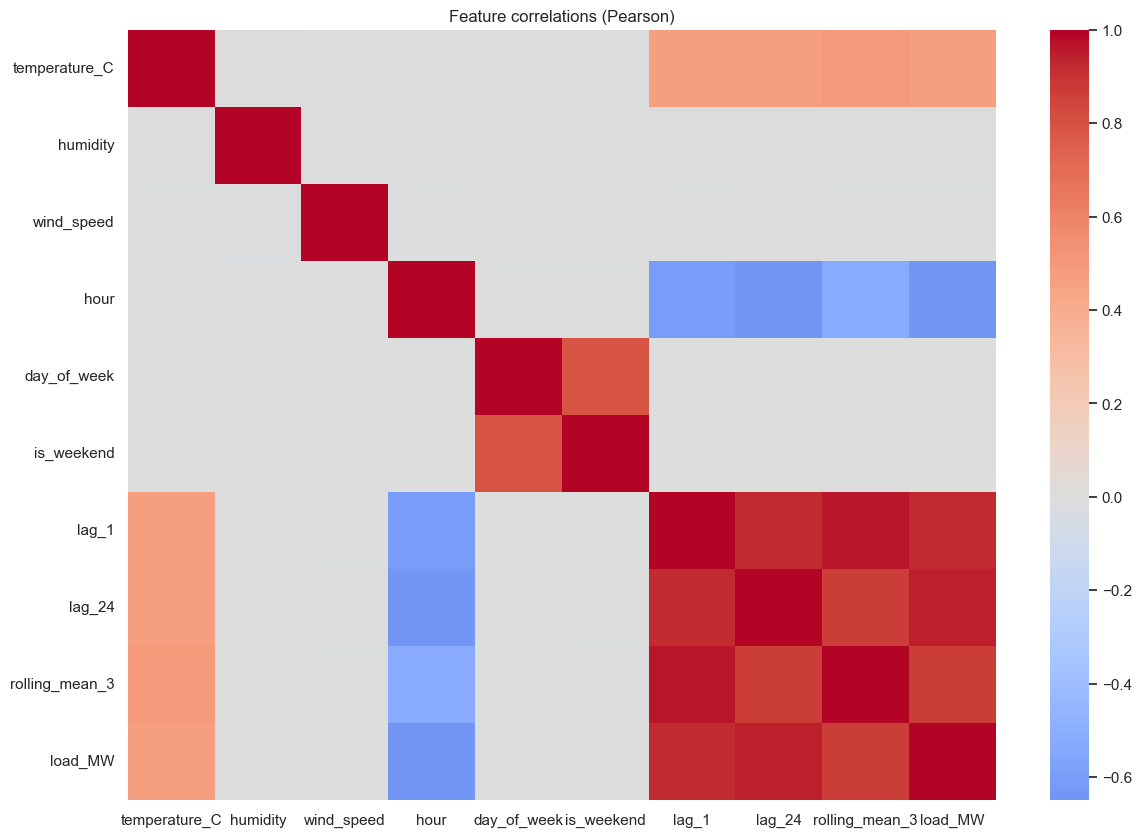

,corr_with_load_MW
lag_24,0.944347
lag_1,0.920122
rolling_mean_3,0.866800
hour,-0.648339
temperature_C,0.474936
humidity,0.003130
is_weekend,0.001889
wind_speed,-0.001178
day_of_week,0.000707


In [10]:
# --- Correlation matrix (Pearson) ---
corr_cols = core_feature_cols + [target_col]
corr = df[corr_cols].corr(method="pearson")

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlations (Pearson)")
plt.show()

# Top correlations with target
target_corr = corr[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)
target_corr.head(15).to_frame("corr_with_load_MW")

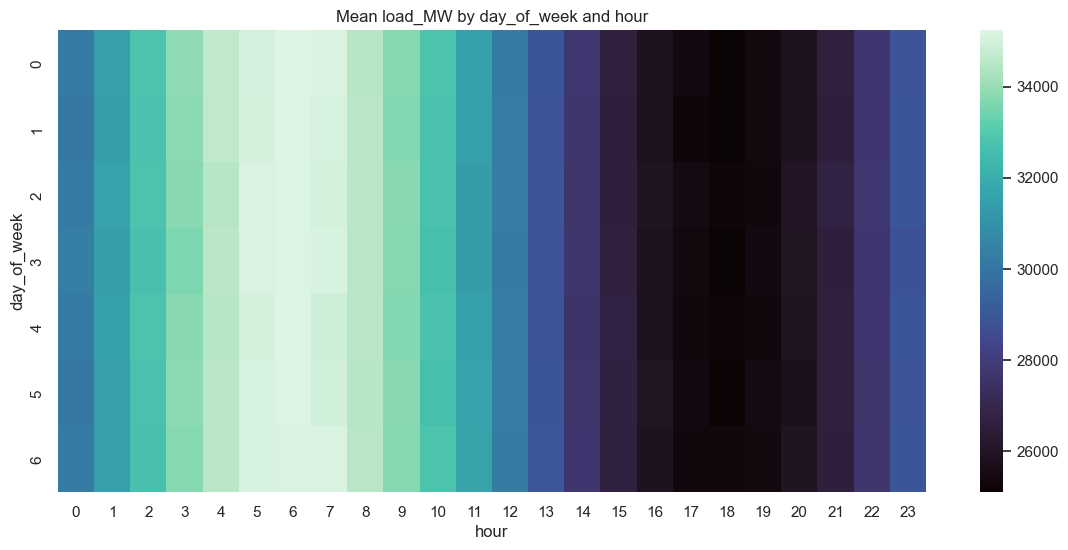

In [11]:
# --- Heatmap: mean load by hour and day_of_week ---
pivot = df.pivot_table(
    index="day_of_week",
    columns="hour",
    values=target_col,
    aggfunc="mean",
)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap="mako")
plt.title("Mean load_MW by day_of_week and hour")
plt.xlabel("hour")
plt.ylabel("day_of_week")
plt.show()


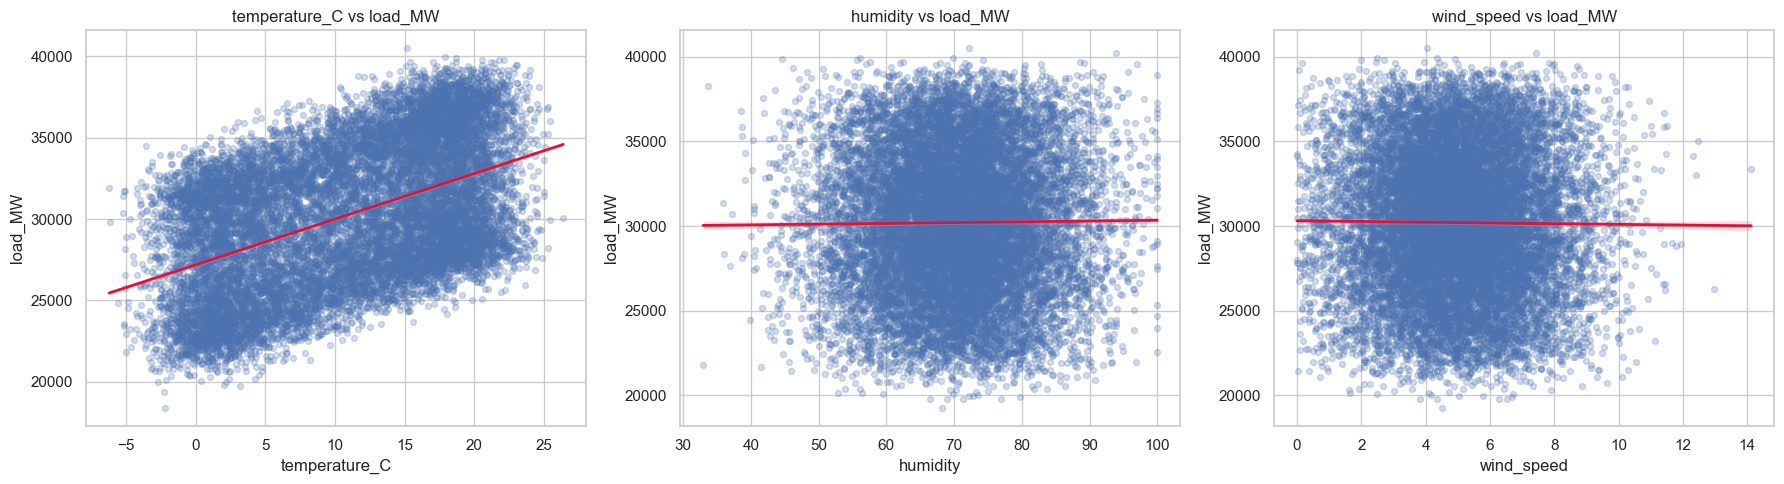

In [12]:
# --- Feature-target relationships (scatter + trend) ---
weather_cols = ["temperature_C", "humidity", "wind_speed"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, weather_cols):
    tmp = df[[col, target_col]].dropna()
    tmp = tmp.sample(n=min(15000, len(tmp)), random_state=RANDOM_STATE) if len(tmp) > 2 else tmp
    sns.regplot(
        data=tmp,
        x=col,
        y=target_col,
        scatter_kws={"alpha": 0.25, "s": 18},
        line_kws={"color": "crimson", "linewidth": 2},
        ax=ax,
    )
    ax.set_title(f"{col} vs load_MW")

plt.tight_layout()
plt.show()


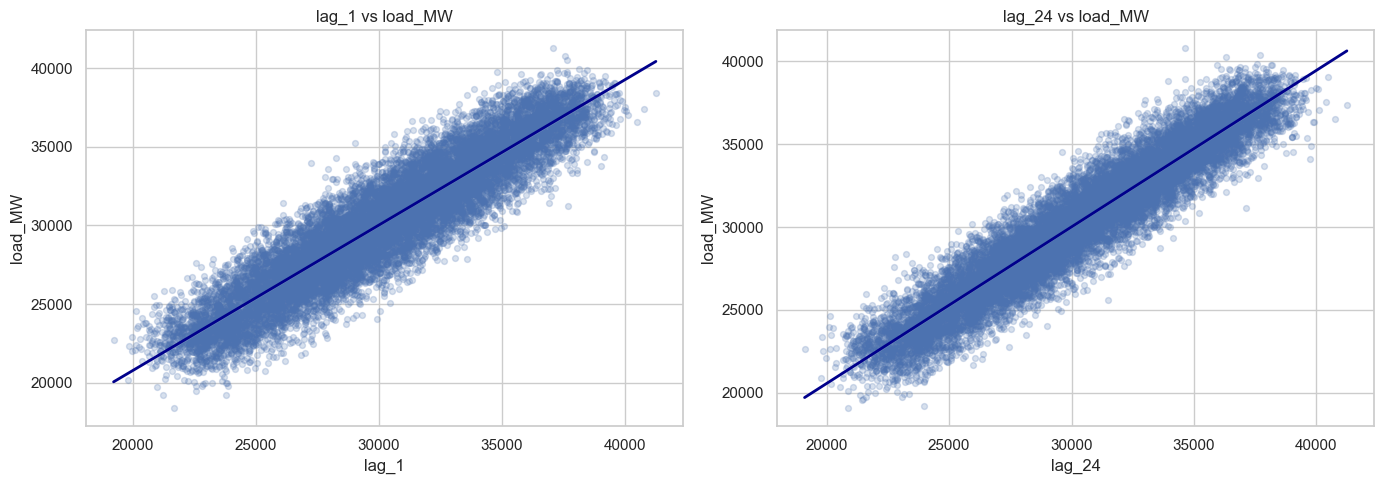

In [13]:
# --- Lag feature relationships ---
lag_cols = ["lag_1", "lag_24"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, lag_cols):
    tmp = df[[col, target_col]].dropna()
    tmp = tmp.sample(n=min(15000, len(tmp)), random_state=RANDOM_STATE) if len(tmp) > 2 else tmp
    sns.regplot(
        data=tmp,
        x=col,
        y=target_col,
        scatter_kws={"alpha": 0.22, "s": 18},
        line_kws={"color": "darkblue", "linewidth": 2},
        ax=ax,
    )
    ax.set_title(f"{col} vs load_MW")

plt.tight_layout()
plt.show()


MODELING: BASELINE + XGBOOST

In [14]:
# --- Preprocessing: split + missing value strategy ---
# XGBoost can handle NaNs, but we still do time-aware imputation for stability.

# Drop rows missing the target (can't supervise training)
df_model = df.dropna(subset=[target_col]).copy()

# Split by time index
n = len(df_model)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

df_train = df_model.iloc[:train_end].copy()
df_val = df_model.iloc[train_end:val_end].copy()
df_test = df_model.iloc[val_end:].copy()

print("Split sizes:")
print({"train": len(df_train), "val": len(df_val), "test": len(df_test)})

# Imputation:
# 1) forward-fill within time (uses only past info for each row)
# 2) fill any remaining NaNs at the start with training medians
df_imputed = df_model.sort_values("timestamp").copy()
df_imputed[core_feature_cols] = df_imputed[core_feature_cols].ffill()

train_medians = df_imputed.iloc[:train_end][core_feature_cols].median()
df_imputed[core_feature_cols] = df_imputed[core_feature_cols].fillna(train_medians)

# Re-slice after imputation
df_train = df_imputed.iloc[:train_end].copy()
df_val = df_imputed.iloc[train_end:val_end].copy()
df_test = df_imputed.iloc[val_end:].copy()

print("Remaining NaNs in features:")
print(df_imputed[core_feature_cols].isna().sum().sort_values(ascending=False))

X_train = df_train[core_feature_cols]
y_train = df_train[target_col]
X_val = df_val[core_feature_cols]
y_val = df_val[target_col]
X_test = df_test[core_feature_cols]
y_test = df_test[target_col]

print("X_train shape:", X_train.shape)


Split sizes:
{'train': 27860, 'val': 5970, 'test': 5970}
Remaining NaNs in features:
temperature_C     0
humidity          0
wind_speed        0
hour              0
day_of_week       0
is_weekend        0
lag_1             0
lag_24            0
rolling_mean_3    0
dtype: int64
X_train shape: (27860, 9)


In [15]:
# --- Metrics helper ---
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float((np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))).mean() * 100.0)

def evaluate(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "MAPE_%": mape(y_true, y_pred),
    }


In [16]:
# --- Baselines ---
# Baseline 1: Seasonal naive (predict with lag_24)
y_pred_naive = df_test["lag_24"].values

# Baseline 2: Simple linear model (Ridge regression)
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

results_baselines = {
    "Naive(lag_24)": evaluate(y_test, y_pred_naive),
    "Ridge": evaluate(y_test, y_pred_ridge),
}

pd.DataFrame(results_baselines).T.sort_values("RMSE")

,RMSE,MAE,R2,MAPE_%
Ridge,1244.449439,995.584734,0.902069,3.262531
Naive(lag_24),1401.145664,1120.909875,0.875855,3.657906


In [18]:
# --- Train XGBoost ---
# If needed, uncomment the following line:
# !pip install xgboost
import xgboost as xgb
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    min_child_weight=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=200,
)

# Early stopping on the validation set
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
    
)

print("Best iteration:", getattr(xgb_model, "best_iteration", None))
print("n_estimators parameter:", xgb_model.get_params().get("n_estimators"))


Best iteration: 273
n_estimators parameter: 5000


In [19]:
# --- Evaluation ---
y_pred_val = xgb_model.predict(X_val)
y_pred_test = xgb_model.predict(X_test)

results_xgb = {
    "XGBoost (val)": evaluate(y_val, y_pred_val),
    "XGBoost (test)": evaluate(y_test, y_pred_test),
}

pd.DataFrame(results_xgb).T

,RMSE,MAE,R2,MAPE_%
XGBoost (val),1090.646677,871.311297,0.936795,3.014010
XGBoost (test),1077.458704,862.764901,0.926588,2.821428


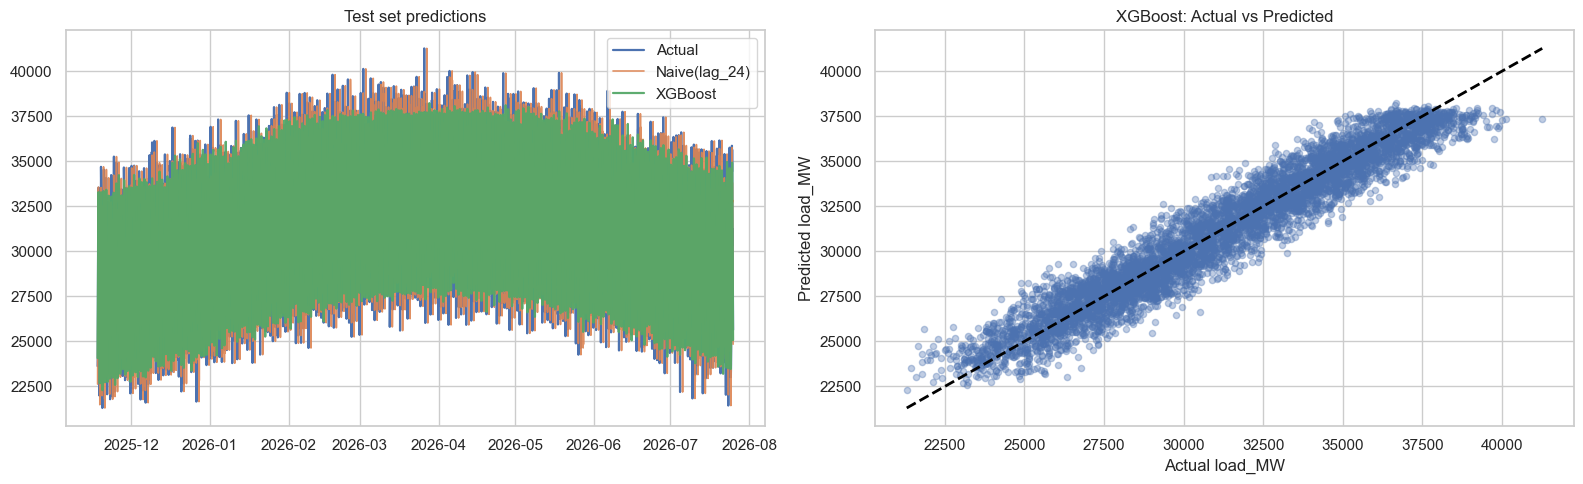

In [20]:
# --- Plots: predictions vs actual ---
df_test_plot = df_test[["timestamp", target_col]].copy()
df_test_plot["pred_naive"] = y_pred_naive
df_test_plot["pred_xgb"] = y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time series comparison
axes[0].plot(df_test_plot["timestamp"], df_test_plot[target_col], label="Actual", linewidth=1.6)
axes[0].plot(df_test_plot["timestamp"], df_test_plot["pred_naive"], label="Naive(lag_24)", linewidth=1.2, alpha=0.9)
axes[0].plot(df_test_plot["timestamp"], df_test_plot["pred_xgb"], label="XGBoost", linewidth=1.6, alpha=0.95)
axes[0].set_title("Test set predictions")
axes[0].legend(loc="upper right")

# Scatter plot (actual vs predicted)
axes[1].scatter(df_test_plot[target_col], df_test_plot["pred_xgb"], alpha=0.35, s=20)
min_v = float(min(df_test_plot[target_col].min(), df_test_plot["pred_xgb"].min()))
max_v = float(max(df_test_plot[target_col].max(), df_test_plot["pred_xgb"].max()))
axes[1].plot([min_v, max_v], [min_v, max_v], linestyle="--", color="black", linewidth=2)
axes[1].set_xlabel("Actual load_MW")
axes[1].set_ylabel("Predicted load_MW")
axes[1].set_title("XGBoost: Actual vs Predicted")

plt.tight_layout()
plt.show()


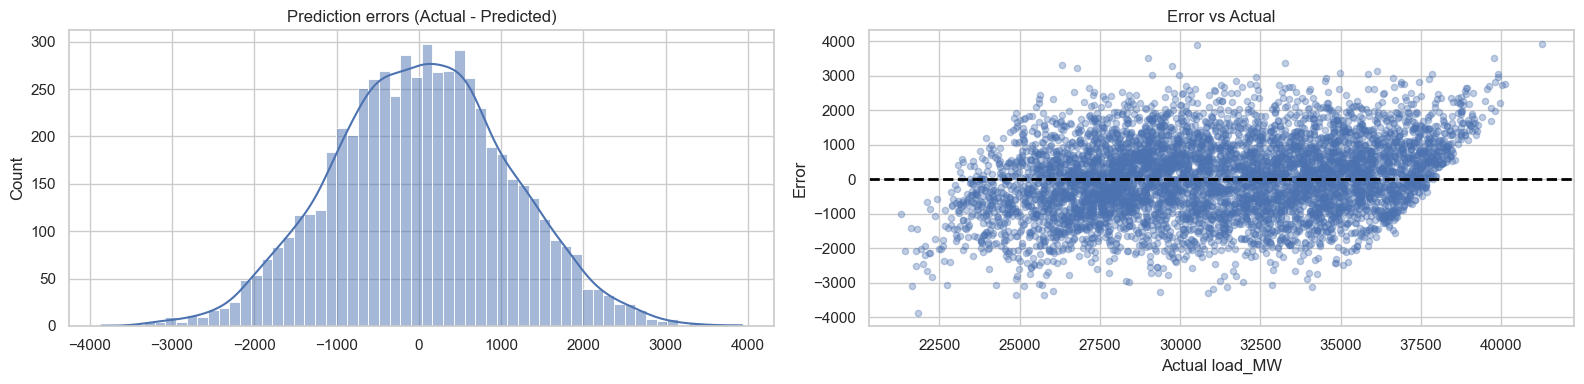

In [21]:
# --- Error analysis ---
errors = y_test.values - y_pred_test
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.histplot(errors, bins=60, kde=True, ax=axes[0])
axes[0].set_title("Prediction errors (Actual - Predicted)")

axes[1].scatter(df_test_plot[target_col], errors, alpha=0.35, s=20)
axes[1].axhline(0, color="black", linewidth=2, linestyle="--")
axes[1].set_xlabel("Actual load_MW")
axes[1].set_ylabel("Error")
axes[1].set_title("Error vs Actual")

plt.tight_layout()
plt.show()


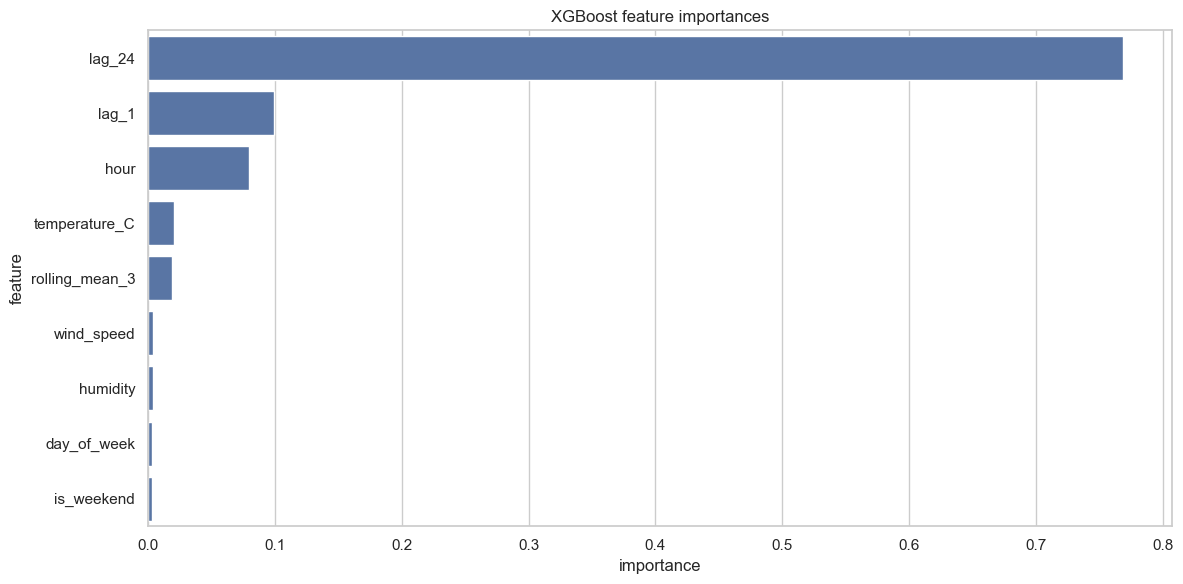

,feature,importance
7,lag_24,0.768728
6,lag_1,0.099167
3,hour,0.079463
0,temperature_C,0.020453
8,rolling_mean_3,0.018793
2,wind_speed,0.003792
1,humidity,0.003715
4,day_of_week,0.003192
5,is_weekend,0.002698


In [22]:
# --- Feature importance ---
importances = xgb_model.feature_importances_
imp_df = pd.DataFrame({"feature": core_feature_cols, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=imp_df.head(12), x="importance", y="feature", orient="h")
plt.title("XGBoost feature importances")
plt.tight_layout()
plt.show()

imp_df.head(15)

## Making Predictions (Inference)

This section shows how to use the trained `xgb_model` to generate predictions.

Key rule: **your inference data must be transformed the same way as training**, especially for lag/rolling features and missing values.

In [24]:
# A) Predict on the test set (quick sanity-check)
# `y_pred_test` was already computed earlier, but this shows the minimal inference call.

y_pred_test_again = xgb_model.predict(X_test)

preview = df_test[["timestamp", target_col]].copy()
preview["pred_xgb"] = y_pred_test_again
preview.head(10)

,timestamp,load_MW,pred_xgb
34005,2025-11-17 21:00:00,23630.662602,24078.953125
34006,2025-11-17 22:00:00,23956.714099,24968.662109
34007,2025-11-17 23:00:00,25892.928787,25926.306641
34008,2025-11-18 00:00:00,27443.303226,27497.210938
34009,2025-11-18 01:00:00,28188.094821,28835.833984
34010,2025-11-18 02:00:00,30694.145658,30063.025391
34011,2025-11-18 03:00:00,31433.180768,31216.017578
34012,2025-11-18 04:00:00,33096.501403,32592.437500
34013,2025-11-18 05:00:00,32360.438440,33284.140625
34014,2025-11-18 06:00:00,33534.733912,32559.646484


In [25]:
# Optional: export test predictions
out_path = "predictions_test_set.csv"
preview.to_csv(out_path, index=False)
print("Wrote:", out_path)

Wrote: predictions_test_set.csv


### B) Predict on a brand-new CSV

Use this when you receive new data for forecasting. The new CSV must contain at least:
- `timestamp`
- `temperature_C`, `humidity`, `wind_speed`, `hour`, `day_of_week`, `is_weekend`

If it already contains `lag_1`, `lag_24`, `rolling_mean_3`, we **still recompute** them from `load_MW` when available, to keep definitions consistent.

Important: for true future forecasting, you need **recent historical `load_MW`** to compute lags/rolling for the first prediction rows.

In [26]:
def prepare_features_for_inference(df_in: pd.DataFrame) -> pd.DataFrame:
    """Prepare inference features using the same logic as training.

    Expected:
    - `timestamp` must be parseable
    - If `load_MW` exists, it will be used only to build lag/rolling features (no future leakage)
      and is NOT required for inference.
    """
    df_new = df_in.copy()

    # Parse + sort time
    df_new["timestamp"] = pd.to_datetime(df_new["timestamp"], errors="coerce")
    df_new = df_new.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    # Recompute safe lag/rolling if load is present (recommended when you have history)
    if "load_MW" in df_new.columns:
        df_new["lag_1"] = df_new["load_MW"].shift(1)
        df_new["lag_24"] = df_new["load_MW"].shift(24)
        df_new["rolling_mean_3"] = df_new["load_MW"].shift(1).rolling(window=3, min_periods=3).mean()

    # Ensure required model features exist
    missing = [c for c in core_feature_cols if c not in df_new.columns]
    if missing:
        raise ValueError(f"Inference data is missing required feature columns: {missing}")

    # Time-safe imputation (same as training): forward-fill then fill remaining with training medians
    df_new[core_feature_cols] = df_new[core_feature_cols].ffill()
    df_new[core_feature_cols] = df_new[core_feature_cols].fillna(train_medians)

    return df_new


# Example usage:
# NEW_DATA_PATH = "new_data.csv"  # <-- replace with your file
# df_new_raw = pd.read_csv(NEW_DATA_PATH)
# df_new_ready = prepare_features_for_inference(df_new_raw)
# X_new = df_new_ready[core_feature_cols]
# df_new_ready["pred_load_MW"] = xgb_model.predict(X_new)
# df_new_ready[["timestamp", "pred_load_MW"]].head()

In [28]:
# Demo (no new file needed): pretend the last 48 rows are "new incoming" data.
# This illustrates the workflow and produces a predictions dataframe.

df_new_raw_demo = df.tail(48).copy()

df_new_ready_demo = prepare_features_for_inference(df_new_raw_demo)
X_new_demo = df_new_ready_demo[core_feature_cols]

df_new_ready_demo["pred_load_MW"] = xgb_model.predict(X_new_demo)

df_new_ready_demo[["timestamp", "load_MW", "pred_load_MW"]].head(12)

,timestamp,load_MW,pred_load_MW
0,2026-07-23 16:00:00,25477.494532,27800.968750
1,2026-07-23 17:00:00,25068.550670,25989.767578
2,2026-07-23 18:00:00,21442.369498,26169.515625
3,2026-07-23 19:00:00,24974.780173,25541.968750
4,2026-07-23 20:00:00,26231.213681,25708.408203
5,2026-07-23 21:00:00,25634.934268,26842.896484
6,2026-07-23 22:00:00,27365.035230,27312.425781
7,2026-07-23 23:00:00,28899.519709,28730.546875
8,2026-07-24 00:00:00,29088.469814,29171.134766
9,2026-07-24 01:00:00,30975.202140,30936.689453


In [29]:
# Optional: export demo predictions
out_path_demo = "predictions_new_data_demo.csv"
cols_out = ["timestamp", "pred_load_MW"]
if "load_MW" in df_new_ready_demo.columns:
    cols_out = ["timestamp", "load_MW", "pred_load_MW"]

df_new_ready_demo[cols_out].to_csv(out_path_demo, index=False)
print("Wrote:", out_path_demo)

Wrote: predictions_new_data_demo.csv


## Export Model Artifacts (for the UI)

Run this after the notebook finishes training. It saves:
- the trained XGBoost model
- `train_medians` used for the same NaN-imputation strategy
- the exact `core_feature_cols` feature list and target name


In [30]:
# Export artifacts for UI inference
import os, json

ARTIFACT_DIR = "ui_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Save model (native xgboost format)
xgb_model.save_model(os.path.join(ARTIFACT_DIR, "xgb_load_model.json"))

# Save imputation medians used by prepare_features_for_inference
train_medians.to_csv(os.path.join(ARTIFACT_DIR, "train_medians.csv"), index=True)

# Save feature list + target
with open(os.path.join(ARTIFACT_DIR, "core_feature_cols.json"), "w") as f:
    json.dump(core_feature_cols, f)

with open(os.path.join(ARTIFACT_DIR, "target_col.json"), "w") as f:
    json.dump(target_col, f)

print("Exported artifacts to:", ARTIFACT_DIR)

Exported artifacts to: ui_artifacts
